In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

C:\Users\91720\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
for dirpath, dirnames, filenames in os.walk(r"C:\Users\91720\Desktop\PRACTICAL IMARTICUS\Capstone project  1&2\Final project 2\project 2\data"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'C:\Users\91720\Desktop\PRACTICAL IMARTICUS\Capstone project  1&2\Final project 2\project 2\data'.
There are 2 directories and 0 images in 'C:\Users\91720\Desktop\PRACTICAL IMARTICUS\Capstone project  1&2\Final project 2\project 2\data\test'.
There are 0 directories and 138 images in 'C:\Users\91720\Desktop\PRACTICAL IMARTICUS\Capstone project  1&2\Final project 2\project 2\data\test\without_mask'.
There are 0 directories and 138 images in 'C:\Users\91720\Desktop\PRACTICAL IMARTICUS\Capstone project  1&2\Final project 2\project 2\data\test\with_mask'.
There are 2 directories and 0 images in 'C:\Users\91720\Desktop\PRACTICAL IMARTICUS\Capstone project  1&2\Final project 2\project 2\data\train'.
There are 0 directories and 548 images in 'C:\Users\91720\Desktop\PRACTICAL IMARTICUS\Capstone project  1&2\Final project 2\project 2\data\train\without_mask'.
There are 0 directories and 552 images in 'C:\Users\91720\Desktop\PRACTICAL IMARTICUS\Capstone pr

In [3]:
base_dir = r"C:\Users\91720\Desktop\PRACTICAL IMARTICUS\Capstone project  1&2\Final project 2\project 2\data"

train_dir = os.path.join(base_dir, 'train')
test_dir  = os.path.join(base_dir, 'test')
img_size = 128
batch_size = 16 
EPOCHS = 30

In [4]:
#random image visuvalization
def show_random_images(folder_path, num_images=4):

    classes = os.listdir(folder_path)

    plt.figure(figsize=(10,4))

    for i in range(num_images):

        random_class = random.choice(classes)
        class_path = os.path.join(folder_path, random_class)

        image_name = random.choice(os.listdir(class_path))
        image_path = os.path.join(class_path, image_name)

        img = Image.open(image_path)

        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.title(random_class)
        plt.axis("off")

    plt.show()

Showing Random Training Images...


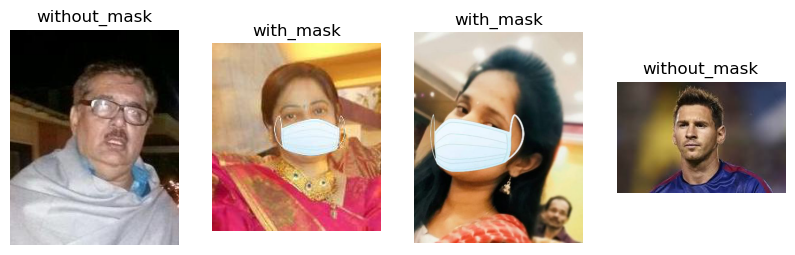

In [5]:
print("Showing Random Training Images...")
show_random_images(train_dir)

Showing Random Training Images...


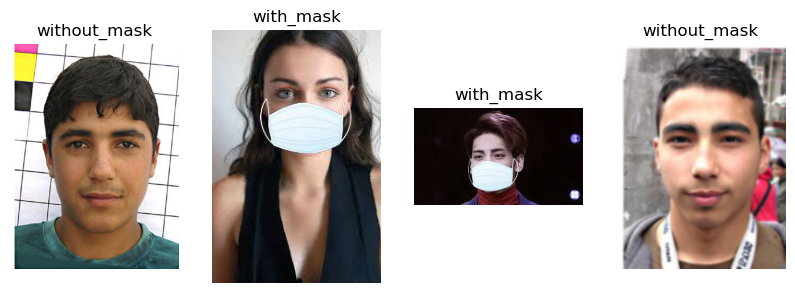

In [6]:
print("Showing Random Training Images...")
show_random_images(test_dir)

In [7]:
#datagenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [30]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 1100 images belonging to 2 classes.


In [31]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

Found 276 images belonging to 2 classes.


In [32]:
#building the cnn model
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu',
                           input_shape=(img_size, img_size, 3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

C:\Users\91720\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
#compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=test_data,
    callbacks=[early_stop]
)
    
    
    


Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 55s 754ms/step - accuracy: 0.5255 - loss: 1.1701 - val_accuracy: 0.5000 - val_loss: 0.6887
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 50s 724ms/step - accuracy: 0.5609 - loss: 0.6566 - val_accuracy: 0.6630 - val_loss: 0.5575
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 54s 774ms/step - accuracy: 0.8027 - loss: 0.5018 - val_accuracy: 0.9239 - val_loss: 0.2934
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 58s 842ms/step - accuracy: 0.8836 - loss: 0.3195 - val_accuracy: 0.9529 - val_loss: 0.2554
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 61s 886ms/step - accuracy: 0.9236 - loss: 0.2425 - val_accuracy: 0.7899 - val_loss: 0.5487
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 59s 858ms/step - accuracy: 0.9236 - loss: 0.2356 - val_accuracy: 0.9529 - val_loss: 0.1124
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 61s 886ms/step - accuracy: 0.9409 - loss: 0.1728 - val_accuracy: 0.9710 - val_loss: 0.0882
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 59s 854ms/step - accuracy: 0.9082 - loss: 0.2636 - val_accu

In [35]:
#Model Evaluation
# Plot the validation and training data separately
import matplotlib.pyplot as plt

def plot_loss_curves(history):

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    epochs = range(len(loss))

    # LOSS GRAPH
    plt.figure(figsize=(6,4))
    plt.plot(epochs, loss, label='training_loss')
    plt.plot(epochs, val_loss, label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.show()

    # ACCURACY GRAPH 
    plt.figure(figsize=(6,4))
    plt.plot(epochs, accuracy, label='training_accuracy')
    plt.plot(epochs, val_accuracy, label='val_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()
    plt.show()

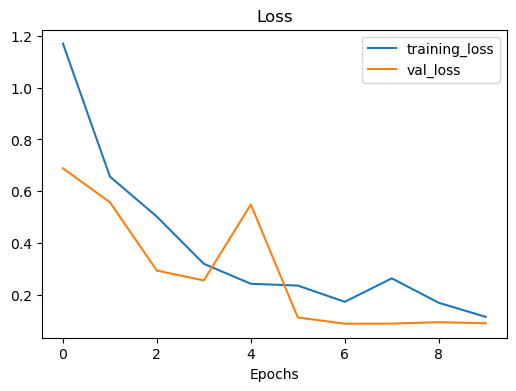

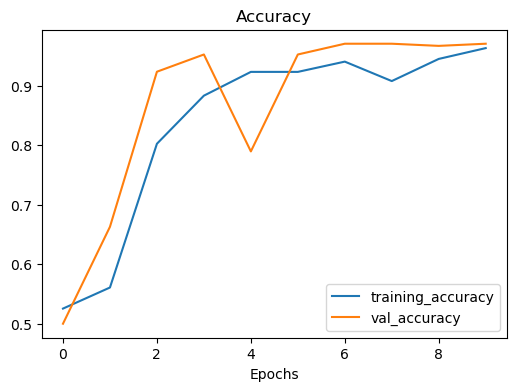

In [36]:
plot_loss_curves(history)

The Face Mask Detection system was successfully developed using CNN and achieved high accuracy of around 97–98%. The model effectively distinguishes between masked and unmasked faces and performs well in real-time webcam detection. This project demonstrates the practical application of deep learning for real-world safety monitoring tasks.

In [37]:
import numpy as np
predictions = model.predict(test_data)
predicted_classes = np.round(predictions).astype(int).flatten()


true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())


18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step


In [38]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nCLASSIFICATION REPORT:\n")
print(classification_report(true_classes, predicted_classes,
                            target_names=class_labels))


CLASSIFICATION REPORT:

              precision    recall  f1-score   support

   with_mask       0.51      0.53      0.52       138
without_mask       0.51      0.50      0.51       138

    accuracy                           0.51       276
   macro avg       0.51      0.51      0.51       276
weighted avg       0.51      0.51      0.51       276



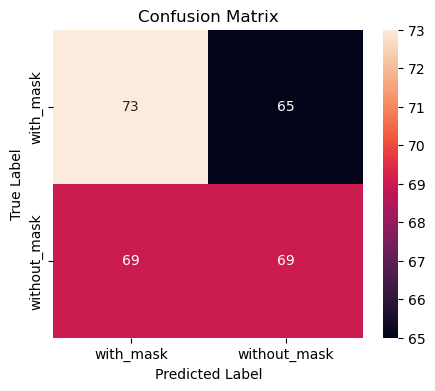

In [39]:
#graph
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [40]:
print(test_data.class_indices)


{'with_mask': 0, 'without_mask': 1}
